# Klinik Rapor Sınıflandırma

`mtsamples` veri setindeki doktor transkripsiyonlarından tıbbi uzmanlık alanını tahmin ediyoruz.

## 1. Keşifsel Veri Analizi

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("mtsamples.csv")

df.info()

df.head()


<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         4999 non-null   int64
 1   description        4999 non-null   str  
 2   medical_specialty  4999 non-null   str  
 3   sample_name        4999 non-null   str  
 4   transcription      4966 non-null   str  
 5   keywords           3931 non-null   str  
dtypes: int64(1), str(5)
memory usage: 234.5 KB


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


### Eksik ve tekrarlı kayıt kontrolü

In [6]:
df.isnull().sum()


Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

Tekrarlı satır yok. `transcription` alanında 33, `keywords` alanında 1068 eksik değer var.

Sınıflandırma `transcription`'a dayandığı için bu alanı boş olan satırlar çıkarılacak.

### Sınıf dağılımı

--- Sınıf Dağılım Tablosu ---
                               Adet  Yüzde (%)
medical_specialty                             
Surgery                        1103      22.06
Consult - History and Phy.      516      10.32
Cardiovascular / Pulmonary      372       7.44
Orthopedic                      355       7.10
Radiology                       273       5.46
General Medicine                259       5.18
Gastroenterology                230       4.60
Neurology                       223       4.46
SOAP / Chart / Progress Notes   166       3.32
Obstetrics / Gynecology         160       3.20
Urology                         158       3.16
Discharge Summary               108       2.16
ENT - Otolaryngology             98       1.96
Neurosurgery                     94       1.88
Hematology - Oncology            90       1.80
Ophthalmology                    83       1.66
Nephrology                       81       1.62
Emergency Room Reports           75       1.50
Pediatrics - Neonatal         

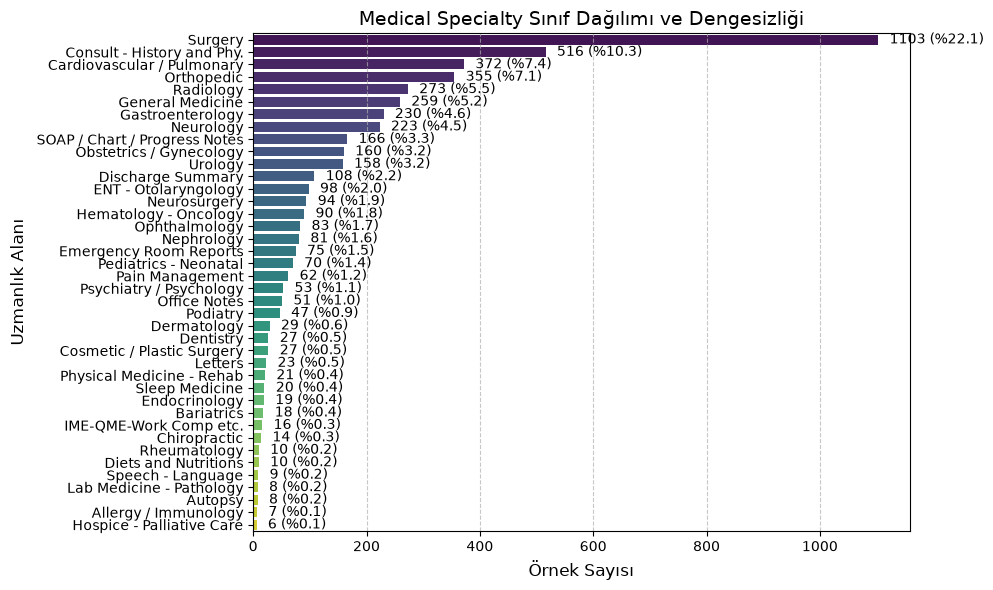

In [8]:
counts = df["medical_specialty"].value_counts()

percentages = df["medical_specialty"].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({"Adet": counts, "Yüzde (%)": percentages.round(2)})

print("--- Sınıf Dağılım Tablosu ---")
print(imbalance_df)

plt.figure(figsize=(10, 6))


ax = sns.barplot(
    x=counts.values, y=counts.index, palette="viridis", hue=counts.index
)

for i, count in enumerate(counts.values):
    ax.text(
        count + 20,
        i,
        f"{count} (%{percentages.values[i]:.1f})",
        va="center",
        fontsize=10,
    )

plt.title("Medical Specialty Sınıf Dağılımı ve Dengesizliği", fontsize=14)
plt.xlabel("Örnek Sayısı", fontsize=12)
plt.ylabel("Uzmanlık Alanı", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

Dağılım ağır dengesiz: 40 sınıfın en büyüğü tek başına verinin ~%22'si, kuyruktakiler 10 örneğin altında. Bu haliyle model kuyruk sınıfları hiç öğrenemez.

## 2. Etiket Düzeltmeleri

Başarıyı asıl kısıtlayan şey model değil, **etiket kalitesi**. İki sınıf çifti içerik olarak birbirinin aynısı.

### 2.1 Consult + General Medicine → General Medical Practice

İkisi de genel anamnez/muayene notu; modeller sürekli birbirine karıştırıyordu. Tek etiket altında birleştirildi.

Ardından en kalabalık 7 sınıf alınıyor. 8. sıradaki `SOAP / Chart / Progress Notes` bilerek dışarıda bırakıldı: bir uzmanlık alanı değil doküman formatı olduğu için tüm sınıflarla çakışıyor.

In [ ]:
import re

df_clean = df.dropna(subset=["transcription"]).copy()

df_clean = df_clean.drop(columns=["Unnamed: 0", "keywords"], errors="ignore")

df_clean["medical_specialty"] = df_clean["medical_specialty"].str.strip()

MERGE_MAP = {
    "Consult - History and Phy.": "General Medical Practice",
    "General Medicine": "General Medical Practice",
}
df_clean["medical_specialty"] = df_clean["medical_specialty"].replace(MERGE_MAP)

print("--- Birleştirme Sonrası Yeni Sınıf ---")
print(df_clean["medical_specialty"].value_counts().head(10))

TOP_N = 7

top_specialties = (
    df_clean["medical_specialty"].value_counts().head(TOP_N).index
)
df_model = df_clean[
    df_clean["medical_specialty"].isin(top_specialties)
].copy()

print(f"\nTop-{TOP_N} Veri Sayısı: {len(df_model)}")
print(df_model["medical_specialty"].value_counts())

print(
    "\n[ARA ADIM] Burada hâlâ 7 sınıf var ve 'Surgery' listede duruyor."
    "\n           Bir sonraki hücrede Surgery düzeltilecek ve sınıf sayısı 6'ya inecek."
)

### 2.2 Surgery etiketinin dağıtılması

Hata analizinde tüm hataların **%50'si** Surgery kaynaklıydı (recall 0.50; 1088 örneğin 240'ı Orthopedic, 142'si Gastroenterology olarak tahmin ediliyordu).

Sebep yine etiket: *Surgery* bir organ sistemi değil, bir işlem türü. Ortopedik bir ameliyat notu gerçekten hem Surgery hem Orthopedic.

Bu yüzden Surgery satırları `sample_name` + `description` alanındaki işlem adına bakılarak ait oldukları organ sistemine geri etiketlendi. Kural tablosuna uymayanlar (üroloji, oftalmoloji, jinekoloji işlemleri — zaten 7 sınıfın dışındalar) ve omurga cerrahisi gibi gerçekten belirsiz olanlar veri setinden çıkarıldı.

> **Sınırlama:** Etiketler `description` anahtar kelimelerinden türetildi ve `transcription` da aynı işlem adlarını içeriyor, yani bir miktar dairesellik var. Bu adımdan sonraki skorlar önceki kurulumla birebir kıyaslanabilir değil.

In [ ]:
from sklearn.preprocessing import LabelEncoder

SURGERY_RELABEL_RULES = [
    (
        "Cardiovascular / Pulmonary",
        r"coronary|cardiac|\bheart\b|angiograph|angioplasty|\bstent|pacemaker|"
        r"defibrillat|aortic|aneurysm|carotid|bypass graft|cabg|valve replace|"
        r"bronchoscop|\blung|thoracotomy|thoracoscop|pleural|chest tube|"
        r"mediastin|vein stripping|varicose|arteriovenous|av fistula|"
        r"femoral artery|endarterectomy|cardiac cath",
    ),
    (
        "Gastroenterology",
        r"colonoscop|esophagogastroduodenoscop|\begd\b|gastroscop|sigmoidoscop|"
        r"upper endoscop|polypectomy|cholecystectomy|gallbladder|appendectomy|"
        r"\bcolon\b|colectomy|hemorrhoid|\bliver\b|hepat|pancrea|\bbowel|ileo|"
        r"jejun|gastric bypass|fundoplication|gastrostomy|anal fissure|rectal|"
        r"esophag",
    ),
    (
        "Orthopedic",
        r"arthroscop|arthroplasty|knee|shoulder|\bhip\b|carpal tunnel|"
        r"rotator cuff|meniscect|meniscus|\bacl\b|\btendon|\bankle|\bwrist|"
        r"\bhand\b|\bfoot\b|bunionect|osteotom|hammertoe|trigger finger|"
        r"ganglion|fracture|\borif\b|hardware removal|humerus|femur|tibia|"
        r"radius|clavicle|patell|dupuytren",
    ),
    (
        "Neurology",
        r"craniotom|ventriculostom|\bvp shunt|shunt placement|ventricular drain|"
        r"craniect|\bbrain\b|intracranial|subdural|nerve block|neuroly|"
        r"ulnar nerve|peripheral nerve",
    ),
]

DROP_AMBIGUOUS = (
    r"discectom|laminectom|spinal fusion|\bfusion\b|vertebroplast|"
    r"cervical spine|lumbar spine|kyphoplast"
)


def relabel_surgery(sample_name, description):
    """Surgery satırını organ sistemine eşler; belirsizse None döner."""
    text = f"{sample_name} {description}".lower()
    if re.search(DROP_AMBIGUOUS, text):
        return None
    for label, pattern in SURGERY_RELABEL_RULES:
        if re.search(pattern, text):
            return label
    return None


surgery_mask = df_model["medical_specialty"] == "Surgery"
df_model.loc[surgery_mask, "medical_specialty"] = [
    relabel_surgery(name, desc)
    for name, desc in zip(
        df_model.loc[surgery_mask, "sample_name"].fillna(""),
        df_model.loc[surgery_mask, "description"].fillna(""),
    )
]

n_before = len(df_model)
df_model = df_model[df_model["medical_specialty"].notna()].copy()
print(f"Eşleşmeyip çıkarılan Surgery satırı: {n_before - len(df_model)}")

df_model = df_model.drop(columns=["sample_name", "description"], errors="ignore")

le = LabelEncoder()
df_model["label"] = le.fit_transform(df_model["medical_specialty"])

print(f"\nSurgery düzeltmesi sonrası veri sayısı: {len(df_model)}")
print(f"Sınıf sayısı: {df_model['medical_specialty'].nunique()}")
print("\nYeni Sınıf Dağılımı (çok daha dengeli):")
print(df_model["medical_specialty"].value_counts())

## 3. Metin Temizliği

Büyük harfli bölüm başlıkları (`HISTORY OF PRESENT ILLNESS:`) siliniyor, kısaltmalar açılıyor (`won't` → `will not`), harf dışı tüm karakterler atılıyor.

In [ ]:
import re


def clean_medical_text(text):
    text = re.sub(r"\b[A-Z\s\/]{3,}:", " ", text)

    text = text.lower()

    text = re.sub(r"won\'t", "will not", text)
    text = re.sub(r"can\'t", "cannot", text)
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)

    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text


df_model["cleaned_transcription"] = df_model["transcription"].apply(
    clean_medical_text
)

Temizlenmiş ilk 5 örnek:

In [ ]:
print(df_model["cleaned_transcription"].head(5))

## 4. Özellik Çıkarımı

**TF-IDF** — 1-3 gram, 5000 özellik, `min_df=3`, `sublinear_tf`. İngilizce stop-word'lere ek olarak bir **medikal stop-word listesi** kullanılıyor: `surgery`, `patient`, `history`, `procedure`, `evaluation` gibi kelimeler her raporda geçtiği için sınıf ayırt ediciliği yok.

**SVD (LSA)** — 5000 boyutlu seyrek uzayda ~2200 örnekle model ezberliyor. 300 gizli konsepte indirgeniyor; hem gürültü azalıyor hem de eşanlamlı terimler (`heart` / `cardiac`) aynı eksende toplanıyor.

Veri sızıntısını önlemek için TF-IDF ve SVD **yalnızca train setinde** fit ediliyor.

## 5. Modeller

In [ ]:
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer


X = df_model["cleaned_transcription"]
y = df_model["label"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Eğitim Seti Boyutu: {len(X_train_raw)}")
print(f"Test Seti Boyutu: {len(X_test_raw)}")

MEDICAL_STOP_WORDS = {
    "history", "procedure", "procedures", "evaluation", "examination", "exam",
    "diagnosis", "diagnoses", "preoperative", "postoperative", "operative",
    "indication", "indications", "findings", "impression", "technique",
    "description", "complaint", "complaints", "chief", "present", "illness",
    "review", "systems", "plan", "assessment", "disposition", "consultation",
    "admission", "discharge", "followup", "follow", "note", "notes", "report",
    "summary", "subjective", "objective", "past", "medical", "surgical",
    "surgery", "medications", "allergies", "family", "social",
    "patient", "patients", "physician", "doctor", "dr", "hospital", "room",
    "clinic", "nurse", "male", "female", "year", "years", "old", "age",
    "date", "time", "day", "days", "week", "weeks", "month", "months",
    "performed", "placed", "noted", "given", "taken", "used", "using",
    "obtained", "revealed", "showed", "shows", "found", "denies", "reports",
    "states", "appears", "well", "normal", "abnormal", "negative", "positive",
    "stable", "condition", "care", "tolerated", "complications", "risks",
    "benefits", "discussed", "informed", "consent", "sterile", "prepped",
    "draped", "fashion", "recovery", "general", "status", "post", "prior",
    "including", "also", "however", "without", "within", "mg", "ml", "cc",
}

STOP_WORDS = list(ENGLISH_STOP_WORDS.union(MEDICAL_STOP_WORDS))
print(f"\nToplam stop-word sayısı: {len(STOP_WORDS)}")

tfidf = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=5000,
    min_df=3,
    sublinear_tf=True,
    stop_words=STOP_WORDS,
)

X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

print("\n--- TF-IDF Sonuçları ---")
print(f"X_train_tfidf Matris Boyutu: {X_train_tfidf.shape}")
print(f"X_test_tfidf Matris Boyutu:  {X_test_tfidf.shape}")

svd = TruncatedSVD(n_components=300, random_state=42)
normalizer = Normalizer()

X_train_svd = normalizer.fit_transform(svd.fit_transform(X_train_tfidf))
X_test_svd = normalizer.transform(svd.transform(X_test_tfidf))

print("\n--- SVD (LSA) Sonuçları ---")
print(f"X_train_svd Matris Boyutu: {X_train_svd.shape}")
print(f"X_test_svd Matris Boyutu:  {X_test_svd.shape}")
print(f"Açıklanan toplam varyans:  {svd.explained_variance_ratio_.sum():.3f}")

### 5.1 Logistic Regression

`C` bu projedeki en baskın parametre: varsayılan `C=1` ile model ezberliyor, optimum bunun çok altında. Sabit değer yazmak yerine train seti üzerinde 5-fold CV ile aranıyor.

Sınıflar dengesiz olduğu için seçim `accuracy`'ye değil **`macro-F1`**'e göre yapılıyor.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.01, 0.03, 0.1, 0.3, 1.0]}

grid = GridSearchCV(
    LogisticRegression(max_iter=4000, class_weight="balanced", random_state=42),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
)
grid.fit(X_train_svd, y_train)

print("--- C Taraması (train, 5-fold CV, macro-F1) ---")
cv_table = pd.DataFrame(
    {
        "C": grid.cv_results_["param_C"],
        "CV macro-F1": grid.cv_results_["mean_test_score"].round(4),
    }
)
print(cv_table.to_string(index=False))
print(f"\nEn iyi C: {grid.best_params_['C']}  (CV macro-F1={grid.best_score_:.4f})")

log_reg = grid.best_estimator_
y_pred = log_reg.predict(X_test_svd)

target_names = le.classes_

print("\n--- Test Seti Sonuçları ---")
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title("Logistic Regression (SVD + tuned C) - Confusion Matrix", fontsize=14)
plt.xlabel("Tahmin Edilen Sınıf", fontsize=12)
plt.ylabel("Gerçek Sınıf", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 5.2 XGBoost

Ağaç modelleri seyrek TF-IDF uzayında zayıf kalıyor; SVD'ye çevirmek de anlamlı fark yaratmadı (0.634 → 0.637). Bu yüzden karşılaştırma amaçlı sparse TF-IDF üzerinde bırakıldı.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1, 
)

xgb_model.fit(X_train_tfidf, y_train)

y_pred_xgb = xgb_model.predict(X_test_tfidf)

target_names = le.classes_

print(
    classification_report(y_test, y_pred_xgb, target_names=target_names, digits=3)
)

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title("XGBoost - Confusion Matrix", fontsize=14)
plt.xlabel("Tahmin Edilen Sınıf", fontsize=12)
plt.ylabel("Gerçek Sınıf", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 5.3 LinearSVC

Optimum `C` değeri LogReg'inkinden bir mertebe daha küçük — hinge loss daha agresif ezberliyor — o yüzden arama aralığı daha aşağıda.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

svc_grid = GridSearchCV(
    LinearSVC(class_weight="balanced", random_state=42, max_iter=5000),
    {"C": [0.003, 0.01, 0.03, 0.1, 0.3]},
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
)
svc_grid.fit(X_train_svd, y_train)

print("--- C Taraması (train, 5-fold CV, macro-F1) ---")
print(
    pd.DataFrame(
        {
            "C": svc_grid.cv_results_["param_C"],
            "CV macro-F1": svc_grid.cv_results_["mean_test_score"].round(4),
        }
    ).to_string(index=False)
)
print(f"\nEn iyi C: {svc_grid.best_params_['C']}")

svc_model = svc_grid.best_estimator_
y_pred_svc = svc_model.predict(X_test_svd)

target_names = le.classes_

print("\n--- Test Seti Sonuçları ---")
print(
    classification_report(y_test, y_pred_svc, target_names=target_names, digits=3)
)

cm_svc = confusion_matrix(y_test, y_pred_svc)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_svc,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title("LinearSVC (SVD + tuned C) - Confusion Matrix", fontsize=14)
plt.xlabel("Tahmin Edilen Sınıf", fontsize=12)
plt.ylabel("Gerçek Sınıf", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()